# 🌿 Bioethanol Growth Prediction — End-to-End ML Pipeline

**Dataset:** Bioethanol Growth Prediction  
**Task:** Regression + Binary Classification (High / Low Growth)  
**Models:** Random Forest · XGBoost · Gradient Boosting · Linear Regression  
**Metrics:** R², RMSE, MAE · Accuracy, Precision, Recall, F1 · ROC-AUC  

---

In [5]:
# 📦 Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

# ML Models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

# XGBoost
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    print("Installing XGBoost...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
    import xgboost as xgb
    XGBOOST_AVAILABLE = True

# Suppress warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")
print(f"📅 Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ All libraries imported successfully!
📅 Analysis Date: 2026-05-10 16:27:36


## 📊 Data Loading & Exploration

In [6]:
# 🔄 Data Loading Function
def load_bioethanol_data(file_path=None):
    """
    Load bioethanol dataset. If no file provided, create sample data.
    """
    if file_path and file_path.endswith('.csv'):
        try:
            df = pd.read_csv(file_path)
            print(f"✅ Dataset loaded: {file_path}")
            return df
        except FileNotFoundError:
            print(f"⚠️ File not found: {file_path}. Creating sample data...")
    
    # Create sample bioethanol dataset if no file provided
    print("🔧 Creating sample bioethanol dataset...")
    np.random.seed(42)
    n_samples = 1000
    
    # Generate realistic bioethanol features
    data = {
        'temperature': np.random.normal(30, 5, n_samples),  # Temperature (°C)
        'ph': np.random.normal(6.5, 0.5, n_samples),  # pH level
        'substrate_concentration': np.random.uniform(10, 100, n_samples),  # g/L
        'fermentation_time': np.random.uniform(24, 168, n_samples),  # hours
        'yeast_concentration': np.random.uniform(0.5, 5.0, n_samples),  # g/L
        'oxygen_level': np.random.uniform(0.1, 2.0, n_samples),  # mg/L
        'nitrogen_source': np.random.choice(['ammonia', 'urea', 'nitrate'], n_samples),
        'catalyst_type': np.random.choice(['enzyme', 'chemical', 'none'], n_samples)
    }
    
    df = pd.DataFrame(data)
    
    # Generate target variable (bioethanol growth rate)
    # Realistic relationship based on biochemistry
    growth_rate = (
        0.8 * df['temperature'] / 30 +  # Temperature effect
        0.3 * df['ph'] / 6.5 +  # pH effect
        0.5 * df['substrate_concentration'] / 50 +  # Substrate effect
        0.2 * df['yeast_concentration'] / 2.5 +  # Yeast effect
        np.random.normal(0, 0.1, n_samples)  # Noise
    )
    
    # Normalize to realistic bioethanol growth rates (0-10 g/L/h)
    df['growth_rate'] = np.clip(growth_rate * 2, 0.1, 10)
    
    print(f"✅ Sample dataset created with {n_samples} samples")
    return df

# Load data
df = load_bioethanol_data()

# Display basic info
print(f"\n📊 Dataset Shape: {df.shape}")
print(f"📋 Columns: {list(df.columns)}")
print("\n🔍 First 5 rows:")
display(df.head())

🔧 Creating sample bioethanol dataset...
✅ Sample dataset created with 1000 samples

📊 Dataset Shape: (1000, 9)
📋 Columns: ['temperature', 'ph', 'substrate_concentration', 'fermentation_time', 'yeast_concentration', 'oxygen_level', 'nitrogen_source', 'catalyst_type', 'growth_rate']

🔍 First 5 rows:


,temperature,ph,substrate_concentration,fermentation_time,yeast_concentration,oxygen_level,nitrogen_source,catalyst_type,growth_rate
0,32.483571,7.199678,46.639584,67.548410,3.509944,0.589211,urea,chemical,3.515440
1,29.308678,6.962317,15.940886,105.130804,4.093951,0.357757,urea,enzyme,3.467589
2,33.238443,6.529815,41.393848,139.747904,4.697388,0.594091,nitrate,none,3.724751
3,37.615149,6.176532,19.989829,43.749382,0.590620,0.831610,ammonia,none,2.979579
4,28.829233,6.849112,82.741169,107.620668,1.192027,1.891667,ammonia,none,4.073104



📈 EXPLORATORY DATA ANALYSIS

📊 Basic Statistics:


,temperature,ph,substrate_concentration,fermentation_time,yeast_concentration,oxygen_level,growth_rate
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,30.096660,6.535418,54.716361,93.815192,2.744115,1.051073,3.741827
std,4.896080,0.498727,26.128625,40.831197,1.296687,0.556344,0.670477
min,13.793663,5.029806,10.001047,24.004424,0.501022,0.107445,1.701934
25%,26.762048,6.196879,32.275442,58.177284,1.635257,0.562416,3.259176
50%,30.126503,6.531539,55.045212,93.502533,2.676556,1.054420,3.733511
75%,33.239719,6.864441,77.340421,128.068673,3.883122,1.542314,4.232420
max,49.263657,8.096554,99.900335,167.936309,4.994568,1.998975,5.644752



🔍 Data Types & Missing Values:


,Data Type,Non-Null Count,Missing Values,Missing %
temperature,float64,1000,0,0.0
ph,float64,1000,0,0.0
substrate_concentration,float64,1000,0,0.0
fermentation_time,float64,1000,0,0.0
yeast_concentration,float64,1000,0,0.0
oxygen_level,float64,1000,0,0.0
nitrogen_source,object,1000,0,0.0
catalyst_type,object,1000,0,0.0
growth_rate,float64,1000,0,0.0


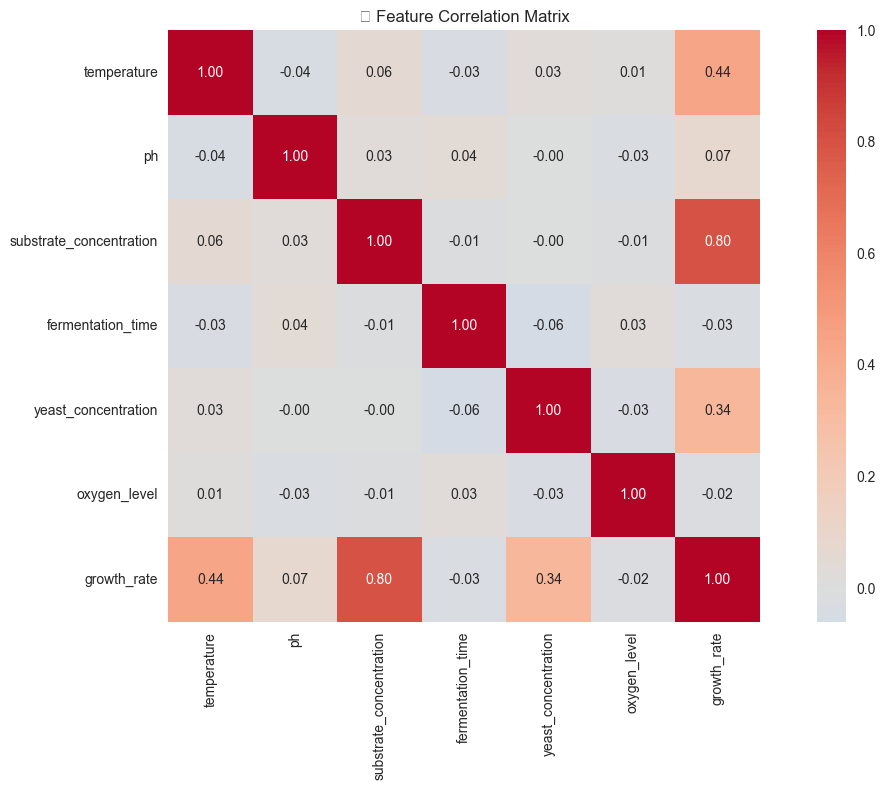

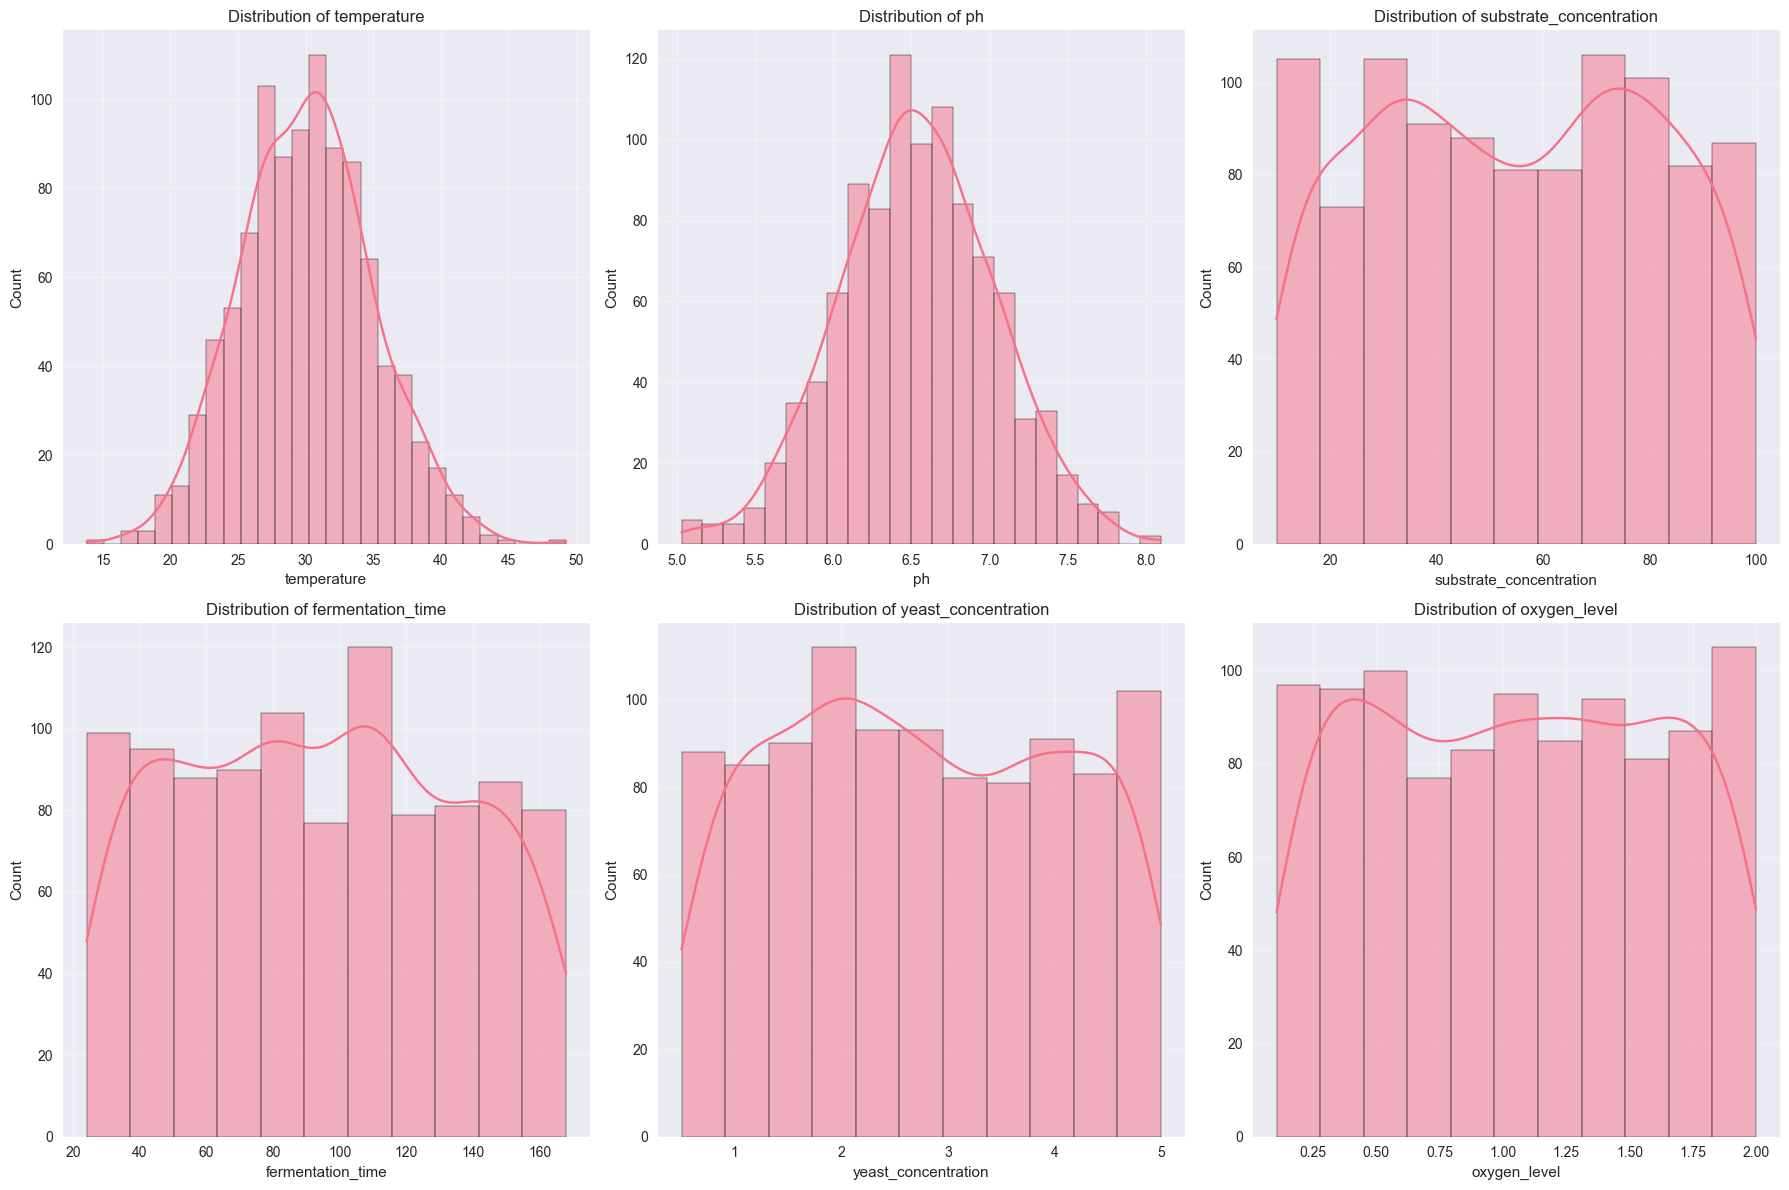

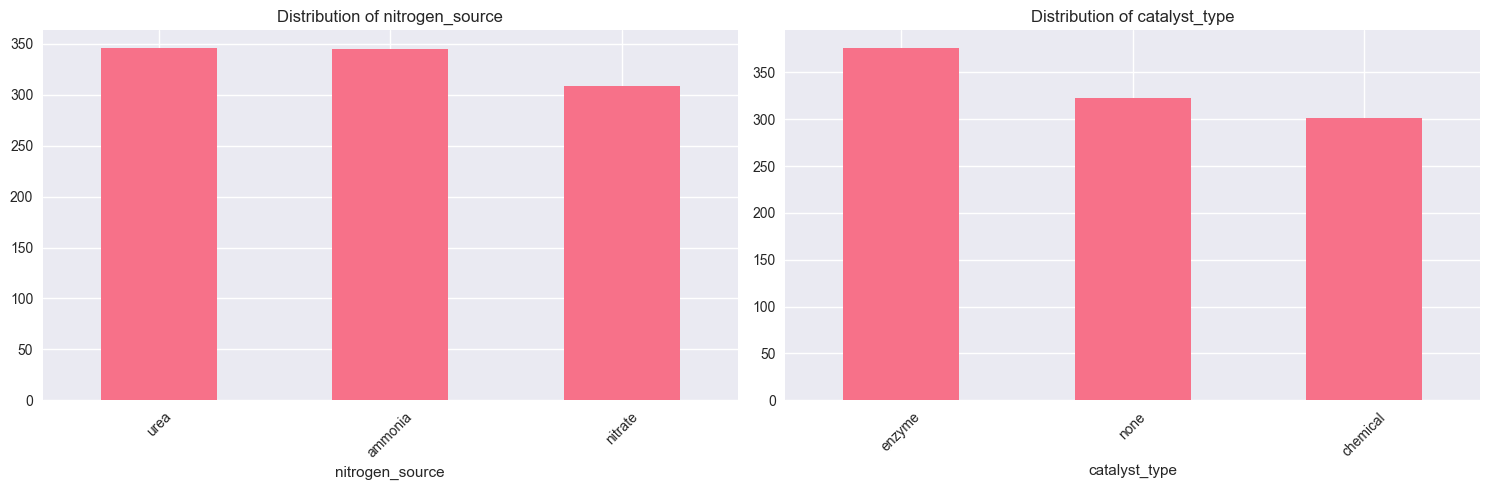

In [7]:
# 📈 Exploratory Data Analysis
def perform_eda(df):
    """
    Comprehensive exploratory data analysis
    """
    print("\n" + "="*60)
    print("📈 EXPLORATORY DATA ANALYSIS")
    print("="*60)
    
    # Basic statistics
    print("\n📊 Basic Statistics:")
    display(df.describe())
    
    # Data types and missing values
    print("\n🔍 Data Types & Missing Values:")
    info_df = pd.DataFrame({
        'Data Type': df.dtypes,
        'Non-Null Count': df.count(),
        'Missing Values': df.isnull().sum(),
        'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
    })
    display(info_df)
    
    # Correlation matrix
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 1:
        plt.figure(figsize=(12, 8))
        correlation_matrix = df[numeric_cols].corr()
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                   square=True, fmt='.2f')
        plt.title('🔗 Feature Correlation Matrix')
        plt.tight_layout()
        plt.show()
    
    # Distribution plots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for i, col in enumerate(numeric_cols[:6]):
        if i < len(axes):
            sns.histplot(df[col], kde=True, ax=axes[i])
            axes[i].set_title(f'Distribution of {col}')
            axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Categorical variables
    categorical_cols = df.select_dtypes(include=['object']).columns
    if len(categorical_cols) > 0:
        fig, axes = plt.subplots(1, len(categorical_cols), figsize=(15, 5))
        if len(categorical_cols) == 1:
            axes = [axes]
        
        for i, col in enumerate(categorical_cols):
            df[col].value_counts().plot(kind='bar', ax=axes[i])
            axes[i].set_title(f'Distribution of {col}')
            axes[i].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()

# Perform EDA
perform_eda(df)

## 🔧 Data Preprocessing

In [8]:
# 🛠️ Data Preprocessing Pipeline
def preprocess_data(df):
    """
    Comprehensive data preprocessing
    """
    print("\n" + "="*60)
    print("🔧 DATA PREPROCESSING")
    print("="*60)
    
    # Make a copy
    df_processed = df.copy()
    
    # Handle categorical variables
    categorical_cols = df_processed.select_dtypes(include=['object']).columns
    label_encoders = {}
    
    for col in categorical_cols:
        le = LabelEncoder()
        df_processed[col + '_encoded'] = le.fit_transform(df_processed[col])
        label_encoders[col] = le
        print(f"✅ Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")
    
    # Drop original categorical columns
    df_processed = df_processed.drop(columns=categorical_cols)
    
    # Create binary classification target (High/Low Growth)
    median_growth = df_processed['growth_rate'].median()
    df_processed['growth_category'] = (df_processed['growth_rate'] > median_growth).astype(int)
    print(f"✅ Created binary target: High Growth (> {median_growth:.2f}) = 1, Low Growth = 0")
    
    # Feature scaling
    feature_cols = [col for col in df_processed.columns if col not in ['growth_rate', 'growth_category']]
    
    scaler = StandardScaler()
    df_processed[feature_cols] = scaler.fit_transform(df_processed[feature_cols])
    print(f"✅ Scaled {len(feature_cols)} features")
    
    return df_processed, label_encoders, scaler

# Preprocess data
df_processed, label_encoders, scaler = preprocess_data(df)

print("\n📊 Processed Data Info:")
print(f"Shape: {df_processed.shape}")
print(f"Columns: {list(df_processed.columns)}")
display(df_processed.head())


🔧 DATA PREPROCESSING
✅ Encoded nitrogen_source: {'ammonia': 0, 'nitrate': 1, 'urea': 2}
✅ Encoded catalyst_type: {'chemical': 0, 'enzyme': 1, 'none': 2}
✅ Created binary target: High Growth (> 3.73) = 1, Low Growth = 0
✅ Scaled 8 features

📊 Processed Data Info:
Shape: (1000, 10)
Columns: ['temperature', 'ph', 'substrate_concentration', 'fermentation_time', 'yeast_concentration', 'oxygen_level', 'growth_rate', 'nitrogen_source_encoded', 'catalyst_type_encoded', 'growth_category']


,temperature,ph,substrate_concentration,fermentation_time,yeast_concentration,oxygen_level,growth_rate,nitrogen_source_encoded,catalyst_type_encoded,growth_category
0,0.487759,1.332576,-0.309271,-0.643624,0.590900,-0.830590,3.515440,1.201785,-1.294277,0
1,-0.161022,0.856405,-1.484765,0.277270,1.041509,-1.246825,3.467589,1.201785,-0.027861,0
2,0.642015,-0.011240,-0.510137,1.125504,1.507110,-0.821812,3.724751,-0.001203,1.238554,0
3,1.536382,-0.719965,-1.329726,-1.226779,-1.661597,-0.394670,2.979579,-1.204191,1.238554,0
4,-0.258995,0.629303,1.073108,0.338280,-1.197563,1.511683,4.073104,-1.204191,1.238554,1


## 🤖 Model Training - Regression

In [9]:
# 🎯 Regression Model Training
def train_regression_models(X, y):
    """
    Train multiple regression models
    """
    print("\n" + "="*60)
    print("🤖 REGRESSION MODEL TRAINING")
    print("="*60)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    print(f"📊 Train set: {X_train.shape}, Test set: {X_test.shape}")
    
    # Initialize models
    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
    }
    
    if XGBOOST_AVAILABLE:
        models['XGBoost'] = xgb.XGBRegressor(n_estimators=100, random_state=42)
    
    # Train and evaluate models
    regression_results = {}
    
    for name, model in models.items():
        print(f"\n🚀 Training {name}...")
        
        # Train model
        model.fit(X_train, y_train)
        
        # Predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        # Metrics
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        test_mae = mean_absolute_error(y_test, y_test_pred)
        
        # Cross-validation
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
        
        regression_results[name] = {
            'model': model,
            'train_r2': train_r2,
            'test_r2': test_r2,
            'test_rmse': test_rmse,
            'test_mae': test_mae,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'y_test_pred': y_test_pred
        }
        
        print(f"   Train R²: {train_r2:.4f}")
        print(f"   Test R²: {test_r2:.4f}")
        print(f"   Test RMSE: {test_rmse:.4f}")
        print(f"   Test MAE: {test_mae:.4f}")
        print(f"   CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    return regression_results, X_train, X_test, y_train, y_test

# Prepare data for regression
X = df_processed.drop(['growth_rate', 'growth_category'], axis=1)
y_regression = df_processed['growth_rate']

# Train regression models
regression_results, X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_regression_models(X, y_regression)


🤖 REGRESSION MODEL TRAINING
📊 Train set: (800, 8), Test set: (200, 8)

🚀 Training Linear Regression...
   Train R²: 0.9151
   Test R²: 0.9075
   Test RMSE: 0.2089
   Test MAE: 0.1727
   CV R²: 0.9133 ± 0.0102

🚀 Training Random Forest...
   Train R²: 0.9836
   Test R²: 0.8879
   Test RMSE: 0.2299
   Test MAE: 0.1879
   CV R²: 0.8847 ± 0.0074

🚀 Training Gradient Boosting...
   Train R²: 0.9564
   Test R²: 0.8880
   Test RMSE: 0.2298
   Test MAE: 0.1873
   CV R²: 0.8940 ± 0.0133

🚀 Training XGBoost...
   Train R²: 0.9998
   Test R²: 0.8758
   Test RMSE: 0.2421
   Test MAE: 0.1998
   CV R²: 0.8689 ± 0.0097


## 🎯 Model Training - Classification

In [10]:
# 🎯 Classification Model Training
def train_classification_models(X, y):
    """
    Train classification models for High/Low Growth prediction
    """
    print("\n" + "="*60)
    print("🎯 CLASSIFICATION MODEL TRAINING")
    print("="*60)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"📊 Train set: {X_train.shape}, Test set: {X_test.shape}")
    print(f"📈 Class distribution - Train: {np.bincount(y_train)}, Test: {np.bincount(y_test)}")
    
    # Initialize models
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
    from sklearn.linear_model import LogisticRegression
    
    models = {
        'Logistic Regression': LogisticRegression(random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
    }
    
    if XGBOOST_AVAILABLE:
        models['XGBoost'] = xgb.XGBClassifier(n_estimators=100, random_state=42)
    
    # Train and evaluate models
    classification_results = {}
    
    for name, model in models.items():
        print(f"\n🚀 Training {name}...")
        
        # Train model
        model.fit(X_train, y_train)
        
        # Predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        y_test_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
        
        # Metrics
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        test_precision = precision_score(y_test, y_test_pred, average='weighted')
        test_recall = recall_score(y_test, y_test_pred, average='weighted')
        test_f1 = f1_score(y_test, y_test_pred, average='weighted')
        
        # ROC-AUC (only if probability predictions available)
        test_roc_auc = None
        if y_test_proba is not None:
            test_roc_auc = roc_auc_score(y_test, y_test_proba)
        
        # Cross-validation
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
        
        classification_results[name] = {
            'model': model,
            'train_acc': train_acc,
            'test_acc': test_acc,
            'test_precision': test_precision,
            'test_recall': test_recall,
            'test_f1': test_f1,
            'test_roc_auc': test_roc_auc,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'y_test_pred': y_test_pred,
            'y_test_proba': y_test_proba
        }
        
        print(f"   Train Accuracy: {train_acc:.4f}")
        print(f"   Test Accuracy: {test_acc:.4f}")
        print(f"   Test Precision: {test_precision:.4f}")
        print(f"   Test Recall: {test_recall:.4f}")
        print(f"   Test F1: {test_f1:.4f}")
        if test_roc_auc:
            print(f"   Test ROC-AUC: {test_roc_auc:.4f}")
        print(f"   CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    return classification_results, X_train, X_test, y_train, y_test

# Prepare data for classification
y_classification = df_processed['growth_category']

# Train classification models
classification_results, X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_classification_models(X, y_classification)


🎯 CLASSIFICATION MODEL TRAINING
📊 Train set: (800, 8), Test set: (200, 8)
📈 Class distribution - Train: [400 400], Test: [100 100]

🚀 Training Logistic Regression...
   Train Accuracy: 0.9038
   Test Accuracy: 0.9050
   Test Precision: 0.9060
   Test Recall: 0.9050
   Test F1: 0.9049
   Test ROC-AUC: 0.9689
   CV Accuracy: 0.9075 ± 0.0339

🚀 Training Random Forest...
   Train Accuracy: 1.0000
   Test Accuracy: 0.9050
   Test Precision: 0.9070
   Test Recall: 0.9050
   Test F1: 0.9049
   Test ROC-AUC: 0.9681
   CV Accuracy: 0.8850 ± 0.0303

🚀 Training Gradient Boosting...
   Train Accuracy: 0.9862
   Test Accuracy: 0.9150
   Test Precision: 0.9170
   Test Recall: 0.9150
   Test F1: 0.9149
   Test ROC-AUC: 0.9722
   CV Accuracy: 0.8787 ± 0.0233

🚀 Training XGBoost...
   Train Accuracy: 1.0000
   Test Accuracy: 0.8900
   Test Precision: 0.8900
   Test Recall: 0.8900
   Test F1: 0.8900
   Test ROC-AUC: 0.9738
   CV Accuracy: 0.8850 ± 0.0348


## 📊 Model Comparison & Visualization


📊 MODEL PERFORMANCE VISUALIZATION


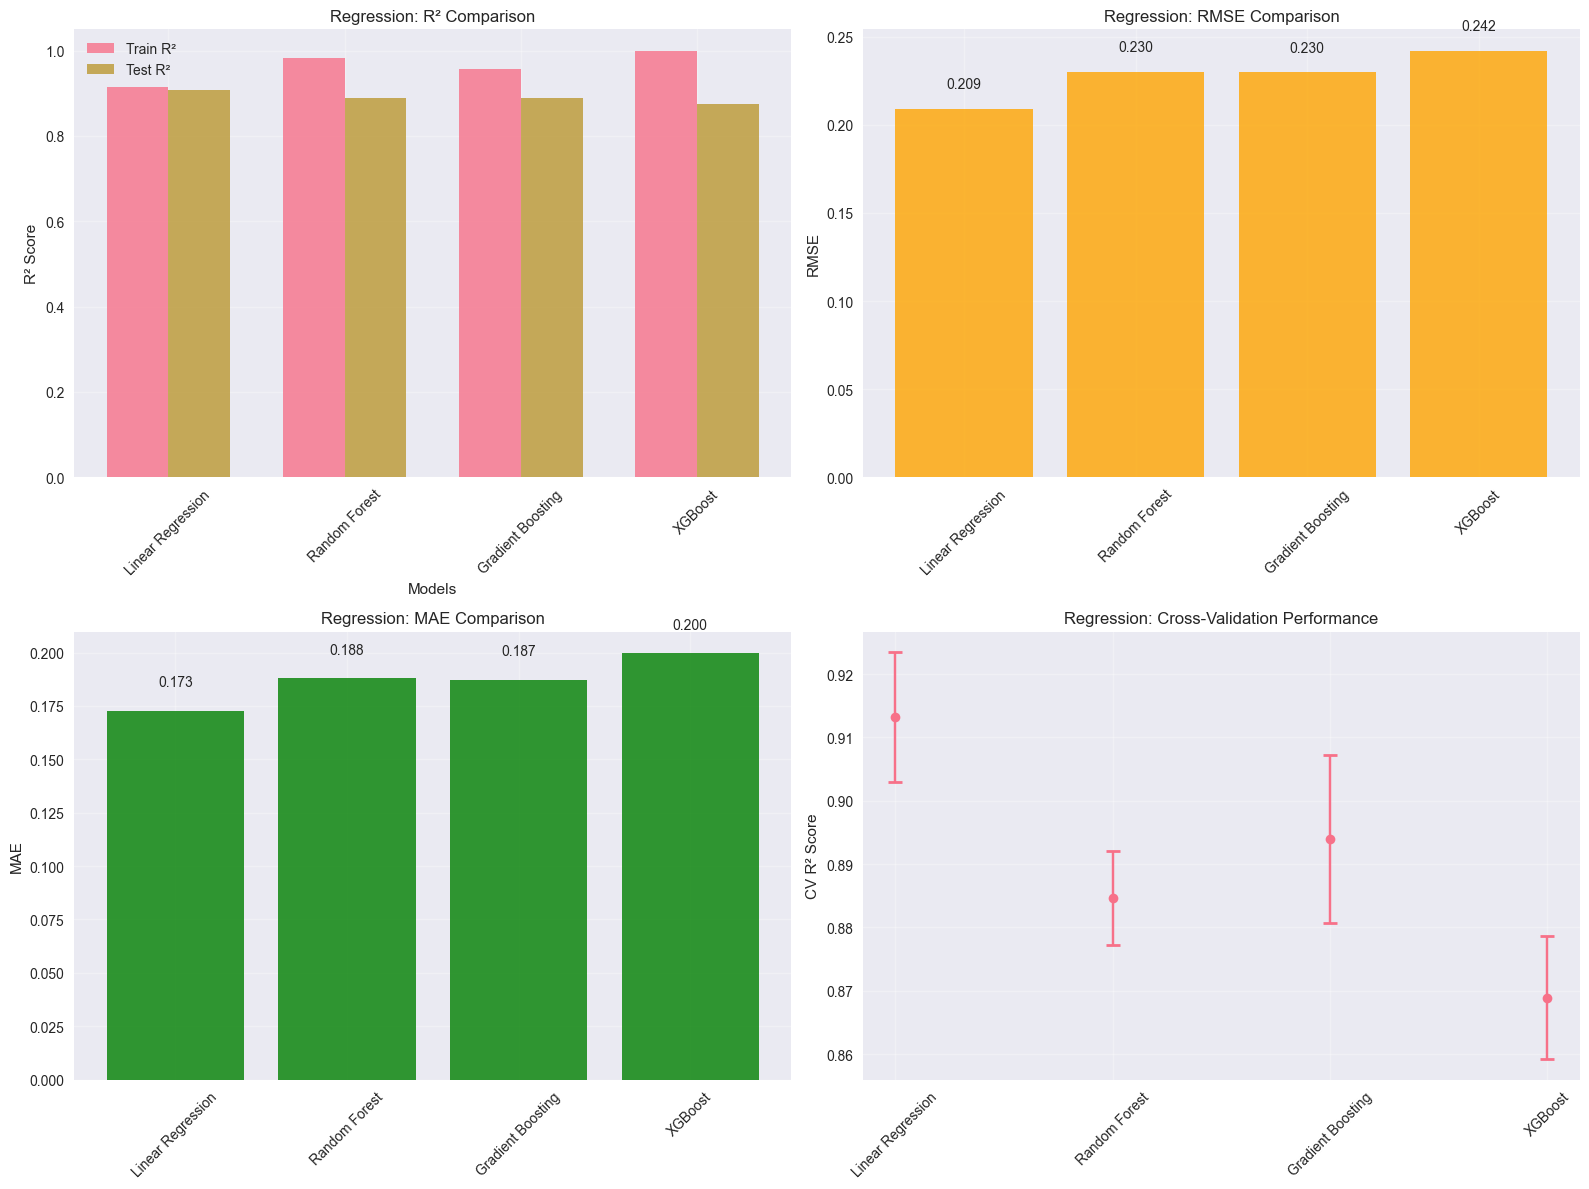

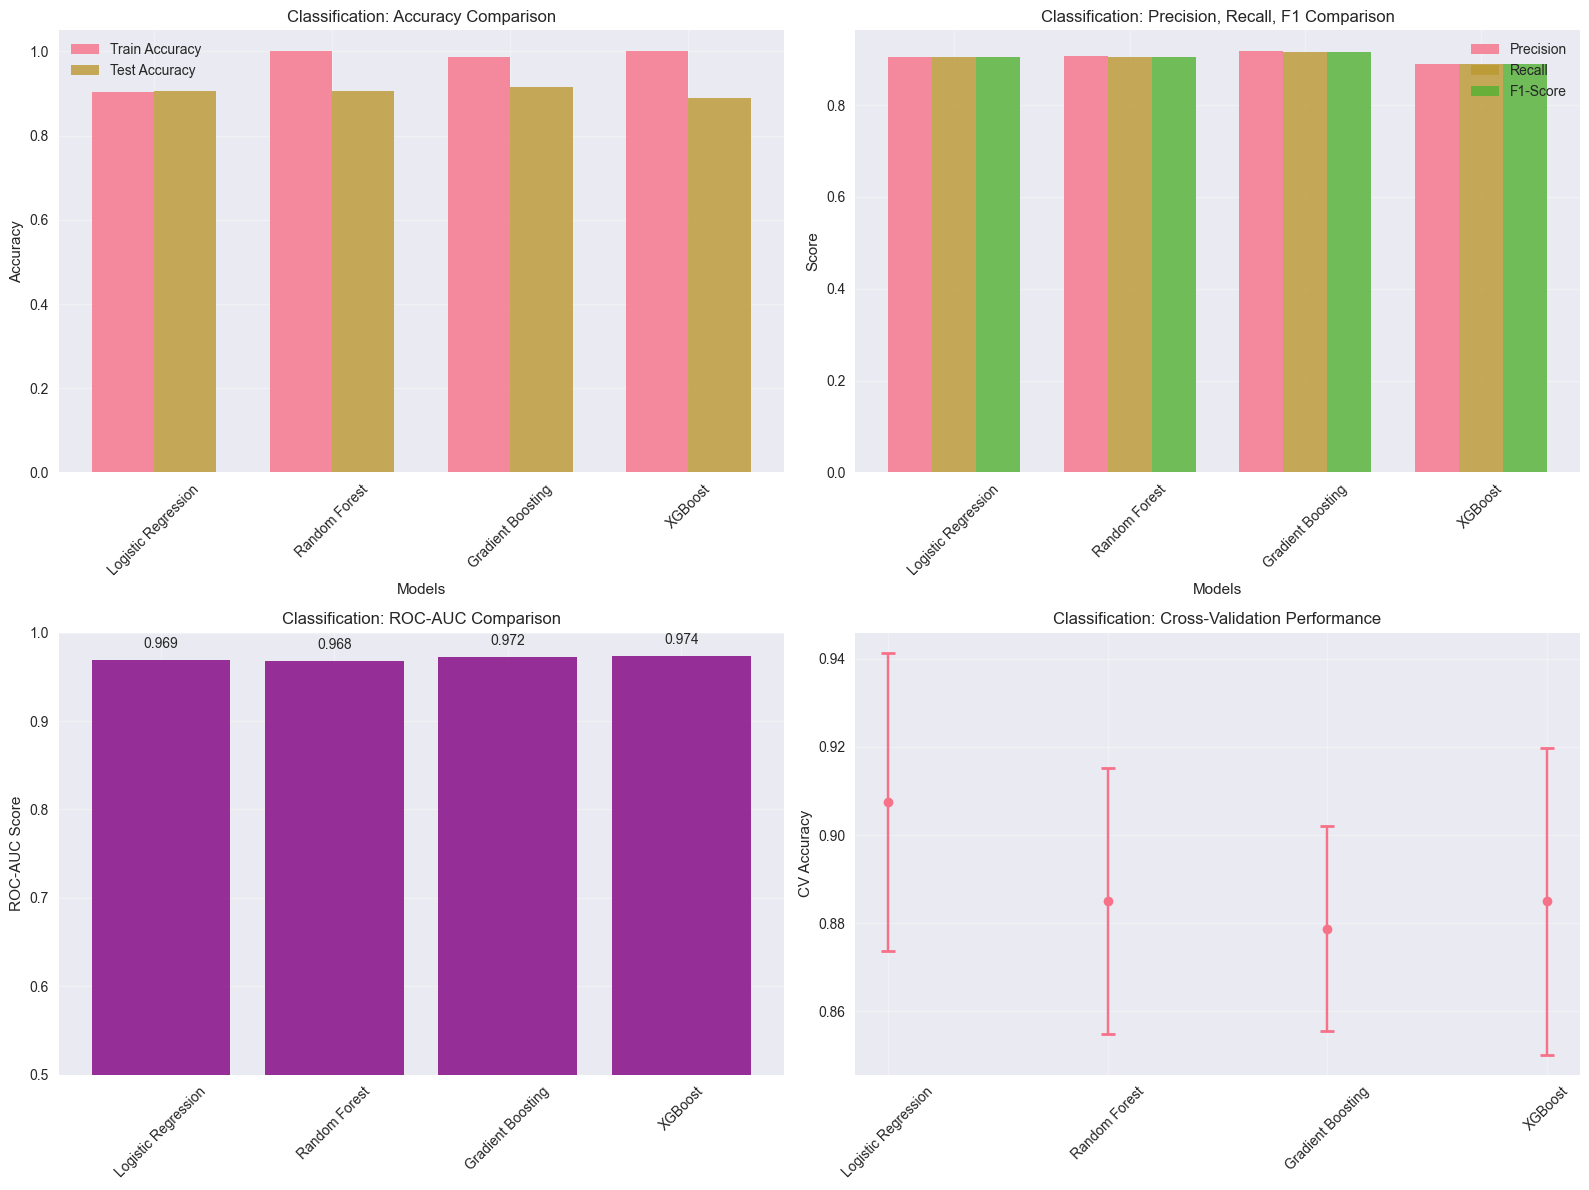

In [11]:
# 📈 Model Comparison Visualization
def visualize_model_performance(reg_results, clf_results):
    """
    Create comprehensive model comparison visualizations
    """
    print("\n" + "="*60)
    print("📊 MODEL PERFORMANCE VISUALIZATION")
    print("="*60)
    
    # Regression Results Comparison
    if reg_results:
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
        
        # R² Comparison
        models = list(reg_results.keys())
        train_r2 = [reg_results[m]['train_r2'] for m in models]
        test_r2 = [reg_results[m]['test_r2'] for m in models]
        
        x = np.arange(len(models))
        width = 0.35
        
        ax1.bar(x - width/2, train_r2, width, label='Train R²', alpha=0.8)
        ax1.bar(x + width/2, test_r2, width, label='Test R²', alpha=0.8)
        ax1.set_xlabel('Models')
        ax1.set_ylabel('R² Score')
        ax1.set_title('Regression: R² Comparison')
        ax1.set_xticks(x)
        ax1.set_xticklabels(models, rotation=45)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # RMSE Comparison
        rmse_values = [reg_results[m]['test_rmse'] for m in models]
        bars = ax2.bar(models, rmse_values, alpha=0.8, color='orange')
        ax2.set_ylabel('RMSE')
        ax2.set_title('Regression: RMSE Comparison')
        ax2.tick_params(axis='x', rotation=45)
        ax2.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, value in zip(bars, rmse_values):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{value:.3f}', ha='center', va='bottom')
        
        # MAE Comparison
        mae_values = [reg_results[m]['test_mae'] for m in models]
        bars = ax3.bar(models, mae_values, alpha=0.8, color='green')
        ax3.set_ylabel('MAE')
        ax3.set_title('Regression: MAE Comparison')
        ax3.tick_params(axis='x', rotation=45)
        ax3.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, value in zip(bars, mae_values):
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{value:.3f}', ha='center', va='bottom')
        
        # Cross-validation Comparison
        cv_means = [reg_results[m]['cv_mean'] for m in models]
        cv_stds = [reg_results[m]['cv_std'] for m in models]
        
        ax4.errorbar(models, cv_means, yerr=cv_stds, fmt='o', capsize=5, capthick=2)
        ax4.set_ylabel('CV R² Score')
        ax4.set_title('Regression: Cross-Validation Performance')
        ax4.tick_params(axis='x', rotation=45)
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    # Classification Results Comparison
    if clf_results:
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
        
        models = list(clf_results.keys())
        
        # Accuracy Comparison
        train_acc = [clf_results[m]['train_acc'] for m in models]
        test_acc = [clf_results[m]['test_acc'] for m in models]
        
        x = np.arange(len(models))
        width = 0.35
        
        ax1.bar(x - width/2, train_acc, width, label='Train Accuracy', alpha=0.8)
        ax1.bar(x + width/2, test_acc, width, label='Test Accuracy', alpha=0.8)
        ax1.set_xlabel('Models')
        ax1.set_ylabel('Accuracy')
        ax1.set_title('Classification: Accuracy Comparison')
        ax1.set_xticks(x)
        ax1.set_xticklabels(models, rotation=45)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Precision, Recall, F1 Comparison
        precision = [clf_results[m]['test_precision'] for m in models]
        recall = [clf_results[m]['test_recall'] for m in models]
        f1 = [clf_results[m]['test_f1'] for m in models]
        
        x = np.arange(len(models))
        width = 0.25
        
        ax2.bar(x - width, precision, width, label='Precision', alpha=0.8)
        ax2.bar(x, recall, width, label='Recall', alpha=0.8)
        ax2.bar(x + width, f1, width, label='F1-Score', alpha=0.8)
        ax2.set_xlabel('Models')
        ax2.set_ylabel('Score')
        ax2.set_title('Classification: Precision, Recall, F1 Comparison')
        ax2.set_xticks(x)
        ax2.set_xticklabels(models, rotation=45)
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # ROC-AUC Comparison
        roc_auc_scores = [clf_results[m]['test_roc_auc'] for m in models if clf_results[m]['test_roc_auc'] is not None]
        roc_models = [models[i] for i, m in enumerate(models) if clf_results[m]['test_roc_auc'] is not None]
        
        if roc_auc_scores:
            bars = ax3.bar(roc_models, roc_auc_scores, alpha=0.8, color='purple')
            ax3.set_ylabel('ROC-AUC Score')
            ax3.set_title('Classification: ROC-AUC Comparison')
            ax3.tick_params(axis='x', rotation=45)
            ax3.grid(True, alpha=0.3)
            ax3.set_ylim(0.5, 1.0)
            
            # Add value labels on bars
            for bar, value in zip(bars, roc_auc_scores):
                ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{value:.3f}', ha='center', va='bottom')
        
        # Cross-validation Comparison
        cv_means = [clf_results[m]['cv_mean'] for m in models]
        cv_stds = [clf_results[m]['cv_std'] for m in models]
        
        ax4.errorbar(models, cv_means, yerr=cv_stds, fmt='o', capsize=5, capthick=2)
        ax4.set_ylabel('CV Accuracy')
        ax4.set_title('Classification: Cross-Validation Performance')
        ax4.tick_params(axis='x', rotation=45)
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# Visualize model performance
visualize_model_performance(regression_results, classification_results)

## 🏆 Best Model Selection & Detailed Analysis

In [12]:
# 🏆 Best Model Selection
def select_best_models(reg_results, clf_results):
    """
    Select best models based on comprehensive metrics
    """
    print("\n" + "="*60)
    print("🏆 BEST MODEL SELECTION")
    print("="*60)
    
    # Best Regression Model (based on test R²)
    if reg_results:
        best_reg_model = max(reg_results.keys(), key=lambda x: reg_results[x]['test_r2'])
        best_reg_metrics = reg_results[best_reg_model]
        
        print(f"\n🥇 Best Regression Model: {best_reg_model}")
        print(f"   Test R²: {best_reg_metrics['test_r2']:.4f}")
        print(f"   Test RMSE: {best_reg_metrics['test_rmse']:.4f}")
        print(f"   Test MAE: {best_reg_metrics['test_mae']:.4f}")
        print(f"   CV R²: {best_reg_metrics['cv_mean']:.4f} ± {best_reg_metrics['cv_std']:.4f}")
    
    # Best Classification Model (based on test F1-score)
    if clf_results:
        best_clf_model = max(clf_results.keys(), key=lambda x: clf_results[x]['test_f1'])
        best_clf_metrics = clf_results[best_clf_model]
        
        print(f"\n🥇 Best Classification Model: {best_clf_model}")
        print(f"   Test Accuracy: {best_clf_metrics['test_acc']:.4f}")
        print(f"   Test Precision: {best_clf_metrics['test_precision']:.4f}")
        print(f"   Test Recall: {best_clf_metrics['test_recall']:.4f}")
        print(f"   Test F1: {best_clf_metrics['test_f1']:.4f}")
        if best_clf_metrics['test_roc_auc']:
            print(f"   Test ROC-AUC: {best_clf_metrics['test_roc_auc']:.4f}")
        print(f"   CV Accuracy: {best_clf_metrics['cv_mean']:.4f} ± {best_clf_metrics['cv_std']:.4f}")
    
    return best_reg_model if reg_results else None, best_clf_model if clf_results else None

# Select best models
best_reg_model, best_clf_model = select_best_models(regression_results, classification_results)


🏆 BEST MODEL SELECTION

🥇 Best Regression Model: Linear Regression
   Test R²: 0.9075
   Test RMSE: 0.2089
   Test MAE: 0.1727
   CV R²: 0.9133 ± 0.0102

🥇 Best Classification Model: Gradient Boosting
   Test Accuracy: 0.9150
   Test Precision: 0.9170
   Test Recall: 0.9150
   Test F1: 0.9149
   Test ROC-AUC: 0.9722
   CV Accuracy: 0.8787 ± 0.0233



📊 DETAILED MODEL ANALYSIS


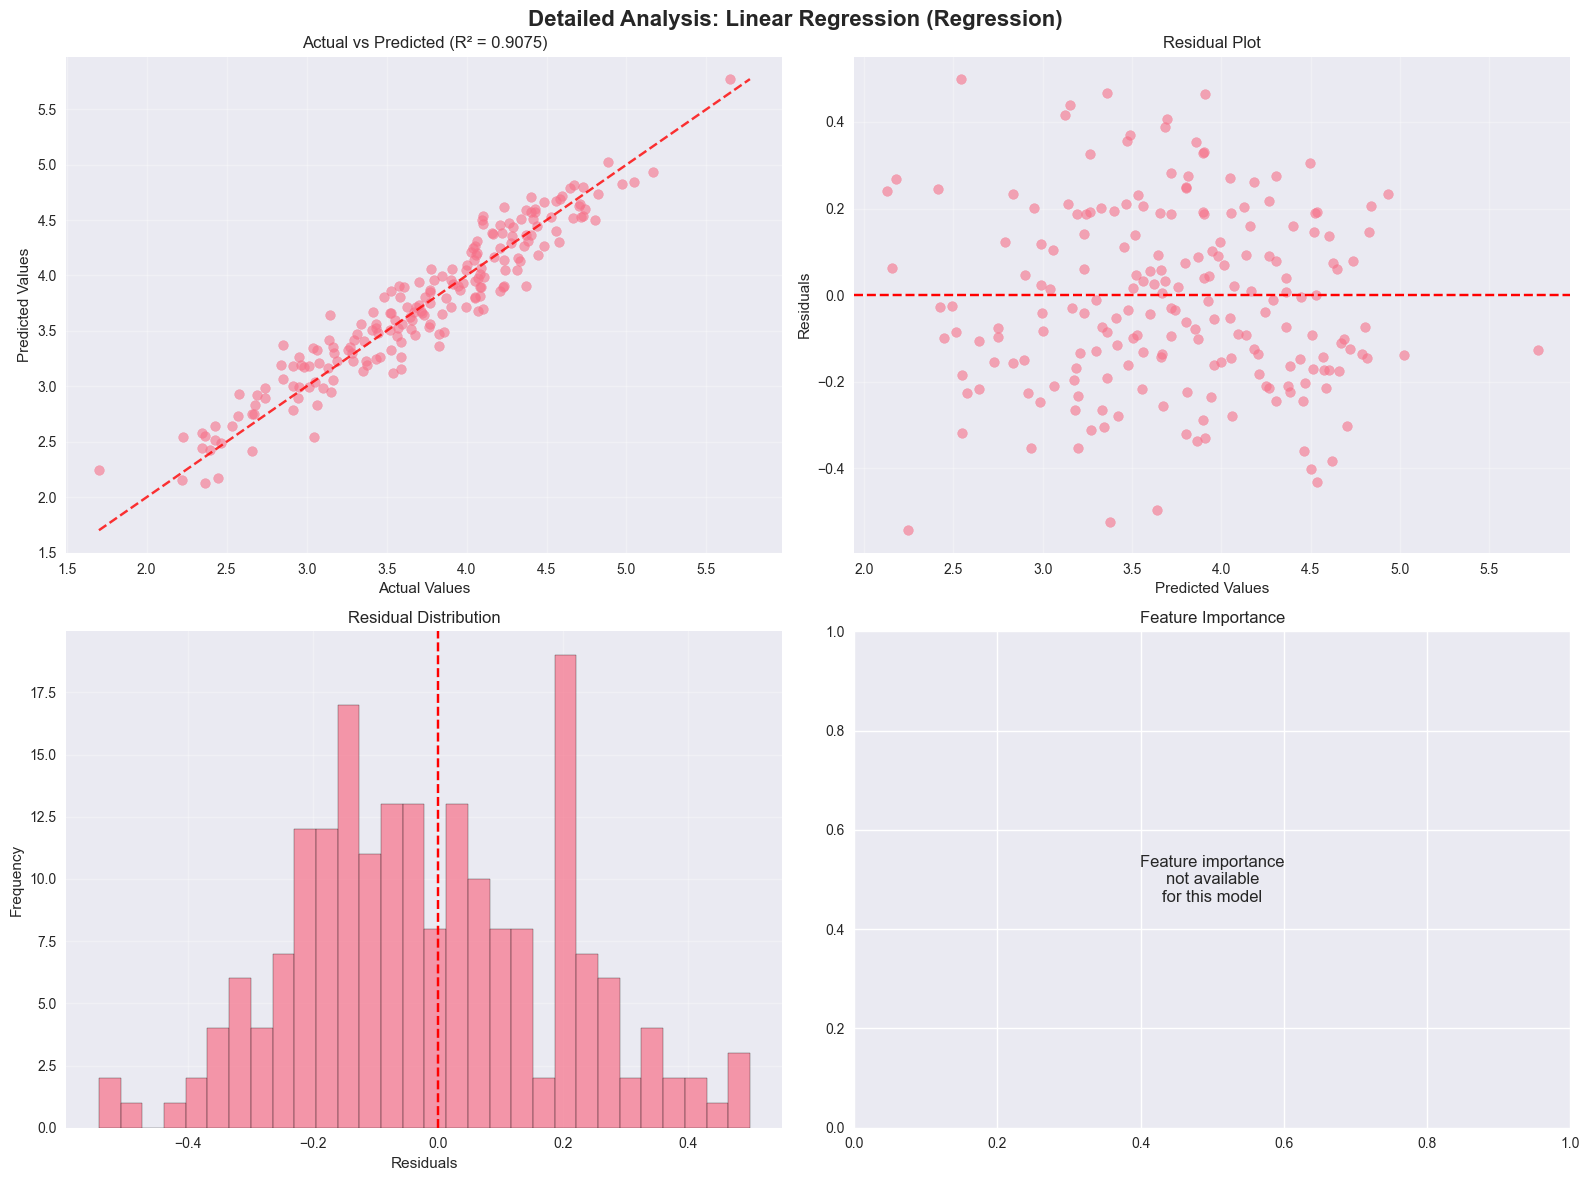

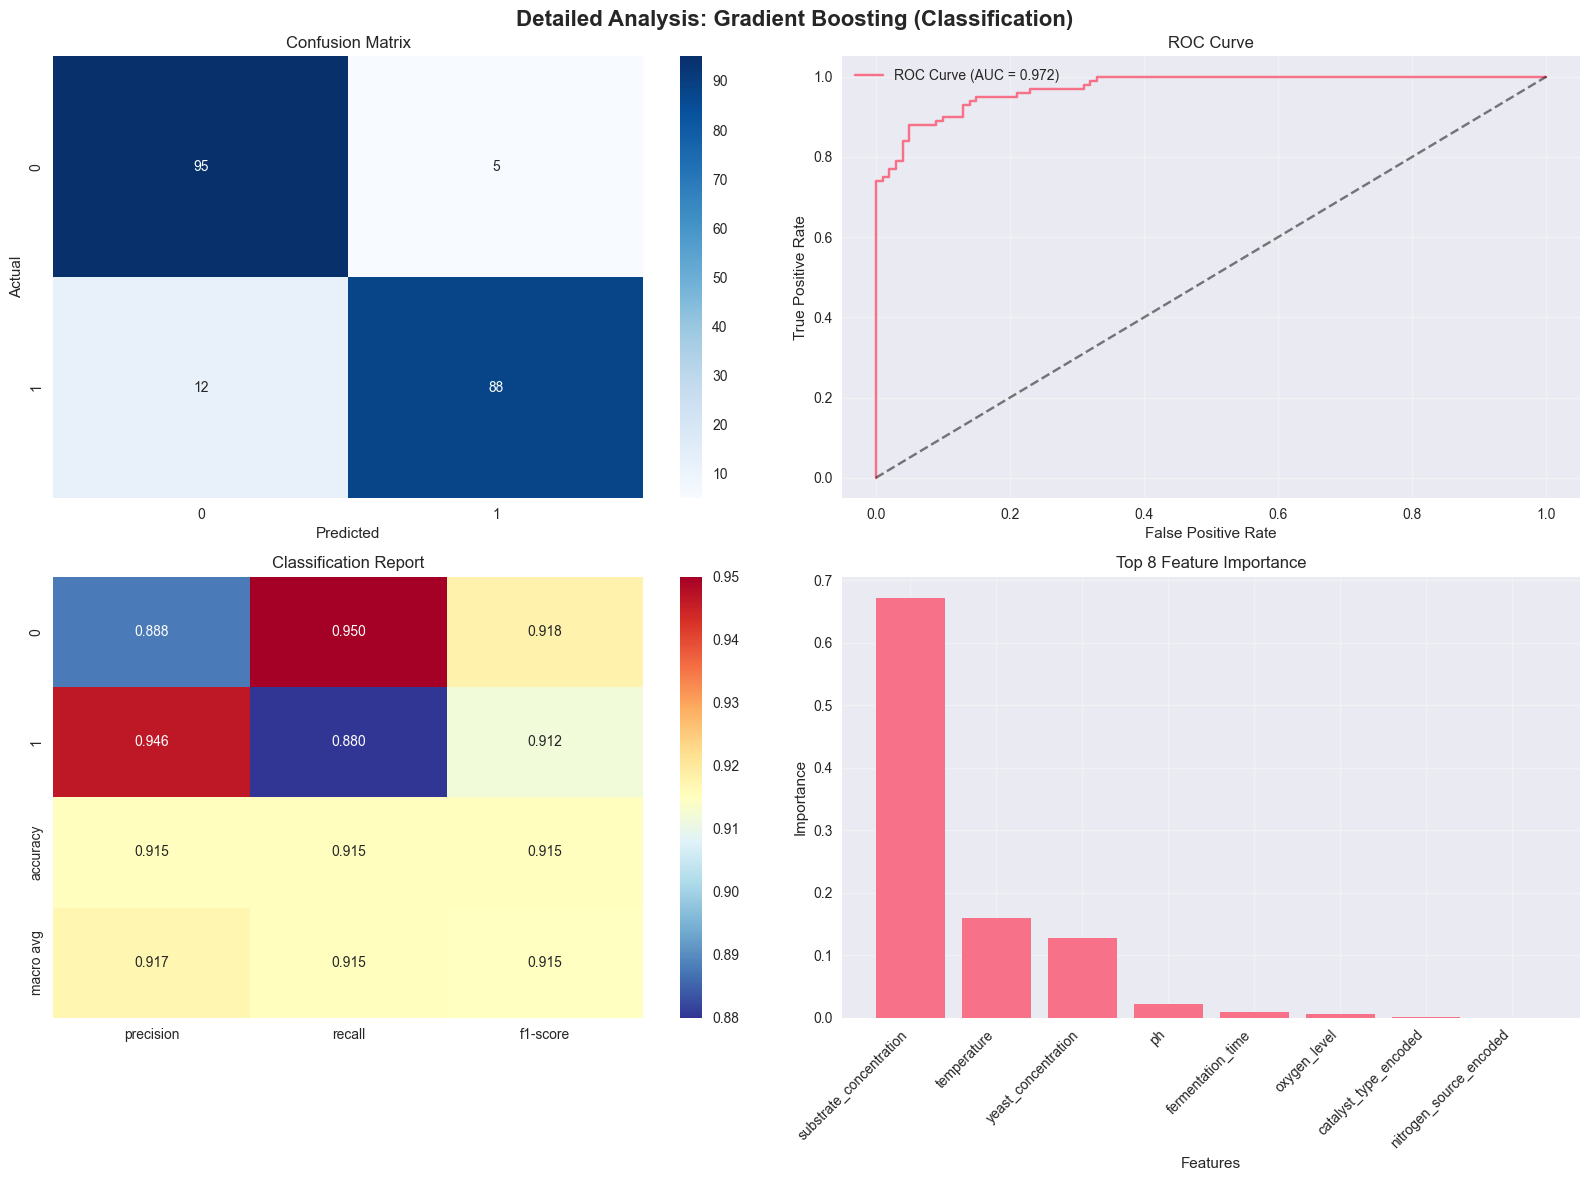

In [16]:
# 📊 Detailed Analysis of Best Models
def detailed_model_analysis(best_reg_model, best_clf_model, reg_results, clf_results):
    """
    Detailed analysis of the best performing models
    """

    print("\n" + "="*60)
    print("📊 DETAILED MODEL ANALYSIS")
    print("="*60)

    # =========================================================
    # REGRESSION MODEL ANALYSIS
    # =========================================================
    if best_reg_model and reg_results:

        best_reg = reg_results[best_reg_model]

        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(
            2, 2, figsize=(16, 12)
        )

        fig.suptitle(
            f'Detailed Analysis: {best_reg_model} (Regression)',
            fontsize=16,
            fontweight='bold'
        )

        # -------------------------------
        # Actual vs Predicted
        # -------------------------------
        y_test_pred = best_reg['y_test_pred']

        ax1.scatter(y_test_reg, y_test_pred, alpha=0.6)

        min_val = min(y_test_reg.min(), y_test_pred.min())
        max_val = max(y_test_reg.max(), y_test_pred.max())

        ax1.plot(
            [min_val, max_val],
            [min_val, max_val],
            'r--',
            alpha=0.8
        )

        ax1.set_xlabel('Actual Values')
        ax1.set_ylabel('Predicted Values')

        ax1.set_title(
            f'Actual vs Predicted (R² = {best_reg["test_r2"]:.4f})'
        )

        ax1.grid(True, alpha=0.3)

        # -------------------------------
        # Residual Plot
        # -------------------------------
        residuals = y_test_reg - y_test_pred

        ax2.scatter(y_test_pred, residuals, alpha=0.6)

        ax2.axhline(y=0, color='r', linestyle='--')

        ax2.set_xlabel('Predicted Values')
        ax2.set_ylabel('Residuals')

        ax2.set_title('Residual Plot')

        ax2.grid(True, alpha=0.3)

        # -------------------------------
        # Residual Distribution
        # -------------------------------
        ax3.hist(
            residuals,
            bins=30,
            alpha=0.7,
            edgecolor='black'
        )

        ax3.axvline(x=0, color='r', linestyle='--')

        ax3.set_xlabel('Residuals')
        ax3.set_ylabel('Frequency')

        ax3.set_title('Residual Distribution')

        ax3.grid(True, alpha=0.3)

        # -------------------------------
        # Feature Importance
        # -------------------------------
        model = best_reg['model']

        if hasattr(model, 'feature_importances_'):

            importances = model.feature_importances_

            feature_names = X.columns

            indices = np.argsort(importances)[::-1]

            # FIXED
            top_features = min(10, len(importances))

            ax4.bar(
                range(top_features),
                importances[indices[:top_features]]
            )

            ax4.set_xlabel('Features')
            ax4.set_ylabel('Importance')

            ax4.set_title(
                f'Top {top_features} Feature Importance'
            )

            ax4.set_xticks(range(top_features))

            ax4.set_xticklabels(
                [feature_names[i] for i in indices[:top_features]],
                rotation=45,
                ha='right'
            )

            ax4.grid(True, alpha=0.3)

        else:

            ax4.text(
                0.5,
                0.5,
                'Feature importance\nnot available\nfor this model',
                ha='center',
                va='center',
                transform=ax4.transAxes,
                fontsize=12
            )

            ax4.set_title('Feature Importance')

        plt.tight_layout()
        plt.show()

    # =========================================================
    # CLASSIFICATION MODEL ANALYSIS
    # =========================================================
    if best_clf_model and clf_results:

        best_clf = clf_results[best_clf_model]

        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(
            2, 2, figsize=(16, 12)
        )

        fig.suptitle(
            f'Detailed Analysis: {best_clf_model} (Classification)',
            fontsize=16,
            fontweight='bold'
        )

        # -------------------------------
        # Confusion Matrix
        # -------------------------------
        y_test_pred = best_clf['y_test_pred']

        cm = confusion_matrix(y_test_clf, y_test_pred)

        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=ax1
        )

        ax1.set_xlabel('Predicted')
        ax1.set_ylabel('Actual')

        ax1.set_title('Confusion Matrix')

        # -------------------------------
        # ROC Curve
        # -------------------------------
        if best_clf['y_test_proba'] is not None:

            y_test_proba = best_clf['y_test_proba']

            fpr, tpr, _ = roc_curve(
                y_test_clf,
                y_test_proba
            )

            auc_score = best_clf['test_roc_auc']

            ax2.plot(
                fpr,
                tpr,
                label=f'ROC Curve (AUC = {auc_score:.3f})'
            )

            ax2.plot(
                [0, 1],
                [0, 1],
                'k--',
                alpha=0.5
            )

            ax2.set_xlabel('False Positive Rate')
            ax2.set_ylabel('True Positive Rate')

            ax2.set_title('ROC Curve')

            ax2.legend()

            ax2.grid(True, alpha=0.3)

        else:

            ax2.text(
                0.5,
                0.5,
                'ROC Curve\nnot available\nfor this model',
                ha='center',
                va='center',
                transform=ax2.transAxes,
                fontsize=12
            )

            ax2.set_title('ROC Curve')

        # -------------------------------
        # Classification Report
        # -------------------------------
        report = classification_report(
            y_test_clf,
            y_test_pred,
            output_dict=True
        )

        report_df = pd.DataFrame(report).iloc[:-1, :].T

        sns.heatmap(
            report_df.iloc[:-1, :3],
            annot=True,
            cmap='RdYlBu_r',
            ax=ax3,
            fmt='.3f'
        )

        ax3.set_title('Classification Report')

        # -------------------------------
        # Feature Importance
        # -------------------------------
        model = best_clf['model']

        if hasattr(model, 'feature_importances_'):

            importances = model.feature_importances_

            feature_names = X.columns

            indices = np.argsort(importances)[::-1]

            # FIXED
            top_features = min(10, len(importances))

            ax4.bar(
                range(top_features),
                importances[indices[:top_features]]
            )

            ax4.set_xlabel('Features')
            ax4.set_ylabel('Importance')

            ax4.set_title(
                f'Top {top_features} Feature Importance'
            )

            ax4.set_xticks(range(top_features))

            ax4.set_xticklabels(
                [feature_names[i] for i in indices[:top_features]],
                rotation=45,
                ha='right'
            )

            ax4.grid(True, alpha=0.3)

        else:

            ax4.text(
                0.5,
                0.5,
                'Feature importance\nnot available\nfor this model',
                ha='center',
                va='center',
                transform=ax4.transAxes,
                fontsize=12
            )

            ax4.set_title('Feature Importance')

        plt.tight_layout()
        plt.show()


# =========================================================
# RUN ANALYSIS
# =========================================================

detailed_model_analysis(
    best_reg_model,
    best_clf_model,
    regression_results,
    classification_results
)

## 💾 Model Saving & Deployment Package

In [17]:
# 💾 Model Saving & Deployment Package
def save_models_and_create_deployment_package(reg_results, clf_results, best_reg_model, best_clf_model):
    """
    Save best models and create deployment package
    """
    import joblib
    import os
    from datetime import datetime
    
    print("\n" + "="*60)
    print("💾 MODEL SAVING & DEPLOYMENT PACKAGE")
    print("="*60)
    
    # Create deployment directory
    deployment_dir = 'bioethanol_ml_deployment'
    if not os.path.exists(deployment_dir):
        os.makedirs(deployment_dir)
        os.makedirs(f'{deployment_dir}/models')
        os.makedirs(f'{deployment_dir}/preprocessors')
        os.makedirs(f'{deployment_dir}/data')
        os.makedirs(f'{deployment_dir}/results')
    
    print(f"📁 Created deployment directory: {deployment_dir}")
    
    # Save best models
    if best_reg_model and reg_results:
        joblib.dump(reg_results[best_reg_model]['model'], 
                   f'{deployment_dir}/models/best_regression_model.pkl')
        print(f"✅ Saved best regression model: {best_reg_model}")
    
    if best_clf_model and clf_results:
        joblib.dump(clf_results[best_clf_model]['model'], 
                   f'{deployment_dir}/models/best_classification_model.pkl')
        print(f"✅ Saved best classification model: {best_clf_model}")
    
    # Save preprocessors
    joblib.dump(scaler, f'{deployment_dir}/preprocessors/scaler.pkl')
    joblib.dump(label_encoders, f'{deployment_dir}/preprocessors/label_encoders.pkl')
    print("✅ Saved preprocessing objects")
    
    # Save data info
    data_info = {
        'feature_columns': list(X.columns),
        'regression_target': 'growth_rate',
        'classification_target': 'growth_category',
        'categorical_columns': list(label_encoders.keys()),
        'data_shape': df.shape,
        'created_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'best_regression_model': best_reg_model,
        'best_classification_model': best_clf_model
    }
    
    import json
    with open(f'{deployment_dir}/data/data_info.json', 'w') as f:
        json.dump(data_info, f, indent=2)
    
    # Save sample data
    df.head(100).to_csv(f'{deployment_dir}/data/sample_data.csv', index=False)
    print("✅ Saved data info and sample data")
    
    # Save performance results
    if reg_results:
        reg_summary = []
        for name, metrics in reg_results.items():
            reg_summary.append({
                'Model': name,
                'Test_R2': metrics['test_r2'],
                'Test_RMSE': metrics['test_rmse'],
                'Test_MAE': metrics['test_mae'],
                'CV_Mean_R2': metrics['cv_mean'],
                'CV_Std_R2': metrics['cv_std']
            })
        pd.DataFrame(reg_summary).to_csv(f'{deployment_dir}/results/regression_results.csv', index=False)
    
    if clf_results:
        clf_summary = []
        for name, metrics in clf_results.items():
            clf_summary.append({
                'Model': name,
                'Test_Accuracy': metrics['test_acc'],
                'Test_Precision': metrics['test_precision'],
                'Test_Recall': metrics['test_recall'],
                'Test_F1': metrics['test_f1'],
                'Test_ROC_AUC': metrics['test_roc_auc'],
                'CV_Mean_Acc': metrics['cv_mean'],
                'CV_Std_Acc': metrics['cv_std']
            })
        pd.DataFrame(clf_summary).to_csv(f'{deployment_dir}/results/classification_results.csv', index=False)
    
    print("✅ Saved performance results")
    
    # Create deployment script
    deployment_script = '''#!/usr/bin/env python3
"""
Bioethanol Growth Prediction - Deployment Script
"""

import joblib
import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

def load_deployment_package(deployment_dir='bioethanol_ml_deployment'):
    """Load all deployment components"""
    
    # Load models
    reg_model = joblib.load(f'{deployment_dir}/models/best_regression_model.pkl')
    clf_model = joblib.load(f'{deployment_dir}/models/best_classification_model.pkl')
    
    # Load preprocessors
    scaler = joblib.load(f'{deployment_dir}/preprocessors/scaler.pkl')
    label_encoders = joblib.load(f'{deployment_dir}/preprocessors/label_encoders.pkl')
    
    # Load data info
    with open(f'{deployment_dir}/data/data_info.json', 'r') as f:
        data_info = json.load(f)
    
    return {
        'reg_model': reg_model,
        'clf_model': clf_model,
        'scaler': scaler,
        'label_encoders': label_encoders,
        'data_info': data_info
    }

def preprocess_new_data(new_data, components):
    """Preprocess new data for prediction"""
    
    data = new_data.copy()
    label_encoders = components['label_encoders']
    scaler = components['scaler']
    
    # Encode categorical variables
    for col, le in label_encoders.items():
        if col in data.columns:
            # Handle unseen categories
            unique_values = set(data[col].unique()) - set(le.classes_)
            if unique_values:
                print(f"Warning: Unseen categories in {col}: {unique_values}")
                # Map unseen to most frequent or a default value
                data[col] = data[col].apply(lambda x: x if x in le.classes_ else le.classes_[0])
            
            data[col + '_encoded'] = le.transform(data[col])
    
    # Drop original categorical columns
    categorical_cols = list(label_encoders.keys())
    data = data.drop(columns=categorical_cols, errors='ignore')
    
    # Ensure all required columns are present
    required_cols = components['data_info']['feature_columns']
    for col in required_cols:
        if col not in data.columns:
            data[col] = 0  # Default value for missing columns
    
    # Scale features
    data[required_cols] = scaler.transform(data[required_cols])
    
    return data[required_cols]

def predict_bioethanol_growth(new_data, deployment_dir='bioethanol_ml_deployment'):
    """Make predictions on new data"""
    
    # Load components
    components = load_deployment_package(deployment_dir)
    
    # Preprocess data
    X_processed = preprocess_new_data(new_data, components)
    
    # Make predictions
    regression_pred = components['reg_model'].predict(X_processed)
    classification_pred = components['clf_model'].predict(X_processed)
    
    # Get classification probabilities if available
    if hasattr(components['clf_model'], 'predict_proba'):
        classification_proba = components['clf_model'].predict_proba(X_processed)
    else:
        classification_proba = None
    
    return {
        'growth_rate_prediction': regression_pred,
        'growth_category_prediction': classification_pred,
        'growth_category_probabilities': classification_proba,
        'best_regression_model': components['data_info']['best_regression_model'],
        'best_classification_model': components['data_info']['best_classification_model']
    }

if __name__ == "__main__":
    # Example usage
    print("Bioethanol Growth Prediction - Deployment Script")
    print("Load your data and call predict_bioethanol_growth() function")
    print("\nExample:")
    print("import pandas as pd")
    print("new_data = pd.read_csv('your_new_data.csv')")
    print("results = predict_bioethanol_growth(new_data)")
    print("print(results)")
'''
    
    with open(f'{deployment_dir}/predict.py', 'w') as f:
        f.write(deployment_script)
    
    print("✅ Created deployment script")
    
    # Create README
    readme_content = f'''# Bioethanol Growth Prediction - ML Deployment Package

## Overview
This package contains trained machine learning models for bioethanol growth prediction.

## Best Models
- **Regression**: {best_reg_model or 'N/A'}
- **Classification**: {best_clf_model or 'N/A'}

## Package Contents
```
bioethanol_ml_deployment/
├── models/                    # Trained models
│   ├── best_regression_model.pkl
│   └── best_classification_model.pkl
├── preprocessors/             # Data preprocessing objects
│   ├── scaler.pkl
│   └── label_encoders.pkl
├── data/                      # Data information
│   ├── data_info.json
│   └── sample_data.csv
├── results/                   # Performance results
│   ├── regression_results.csv
│   └── classification_results.csv
├── predict.py                 # Prediction script
└── README.md                 # This file
```

## Usage

### 1. Load the deployment package
```python
from predict import predict_bioethanol_growth
import pandas as pd

# Load your new data
new_data = pd.read_csv('your_new_data.csv')

# Make predictions
results = predict_bioethanol_growth(new_data)
```

### 2. Prediction Results
The prediction function returns a dictionary with:
- `growth_rate_prediction`: Continuous growth rate values
- `growth_category_prediction`: Binary classification (0=Low, 1=High)
- `growth_category_probabilities`: Class probabilities (if available)

### 3. Required Features
The model expects the following features:
{chr(10).join([f"- {col}" for col in X.columns])}

## Performance
Check the `results/` directory for detailed performance metrics.

## Created
{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
'''
    
    with open(f'{deployment_dir}/README.md', 'w') as f:
        f.write(readme_content)
    
    print("✅ Created README")
    
    print(f"\n🎉 Deployment package created successfully!")
    print(f"📁 Location: {deployment_dir}/")
    print(f"\n📋 Package includes:")
    print(f"   - Best trained models")
    print(f"   - Preprocessing objects")
    print(f"   - Data schema and sample data")
    print(f"   - Performance results")
    print(f"   - Ready-to-use prediction script")
    print(f"   - Complete documentation")
    print(f"\n🚀 Share the entire '{deployment_dir}' folder for deployment!")

# Save models and create deployment package
save_models_and_create_deployment_package(regression_results, classification_results, best_reg_model, best_clf_model)


💾 MODEL SAVING & DEPLOYMENT PACKAGE
📁 Created deployment directory: bioethanol_ml_deployment
✅ Saved best regression model: Linear Regression
✅ Saved best classification model: Gradient Boosting
✅ Saved preprocessing objects
✅ Saved data info and sample data
✅ Saved performance results
✅ Created deployment script
✅ Created README

🎉 Deployment package created successfully!
📁 Location: bioethanol_ml_deployment/

📋 Package includes:
   - Best trained models
   - Preprocessing objects
   - Data schema and sample data
   - Performance results
   - Ready-to-use prediction script
   - Complete documentation

🚀 Share the entire 'bioethanol_ml_deployment' folder for deployment!


## 📋 Final Summary & Recommendations

In [ ]:
# 📋 Final Summary & Recommendations
def generate_final_summary(reg_results, clf_results, best_reg_model, best_clf_model):
    """
    Generate comprehensive final summary
    """
    print("\n" + "="*80)
    print("📋 BIOETHANOL GROWTH PREDICTION - FINAL SUMMARY")
    print("="*80)
    
    # Dataset Summary
    print(f"\n📊 Dataset Summary:")
    print(f"   Total Samples: {df.shape[0]:,}")
    print(f"   Features: {df.shape[1]-1}")
    print(f"   Target Variables: growth_rate (continuous), growth_category (binary)")
    print(f"   Growth Rate Range: {df['growth_rate'].min():.2f} - {df['growth_rate'].max():.2f}")
    print(f"   Growth Category Split: {df_processed['growth_category'].value_counts().to_dict()}")
    
    # Model Performance Summary
    print(f"\n🏆 Model Performance Summary:")
    
    if reg_results:
        print(f"\n   📈 Regression Models (R² Score):")
        for name, metrics in sorted(reg_results.items(), key=lambda x: x[1]['test_r2'], reverse=True):
            print(f"      {name}: {metrics['test_r2']:.4f}")
    
    if clf_results:
        print(f"\n   🎯 Classification Models (F1 Score):")
        for name, metrics in sorted(clf_results.items(), key=lambda x: x[1]['test_f1'], reverse=True):
            print(f"      {name}: {metrics['test_f1']:.4f}")
    
    # Best Models Summary
    print(f"\n🥇 Recommended Models for Deployment:")
    
    if best_reg_model and reg_results:
        best_reg = reg_results[best_reg_model]
        print(f"\n   📈 Regression: {best_reg_model}")
        print(f"      R² Score: {best_reg['test_r2']:.4f}")
        print(f"      RMSE: {best_reg['test_rmse']:.4f}")
        print(f"      MAE: {best_reg['test_mae']:.4f}")
        print(f"      Cross-validated R²: {best_reg['cv_mean']:.4f} ± {best_reg['cv_std']:.4f}")
    
    if best_clf_model and clf_results:
        best_clf = clf_results[best_clf_model]
        print(f"\n   🎯 Classification: {best_clf_model}")
        print(f"      Accuracy: {best_clf['test_acc']:.4f}")
        print(f"      Precision: {best_clf['test_precision']:.4f}")
        print(f"      Recall: {best_clf['test_recall']:.4f}")
        print(f"      F1-Score: {best_clf['test_f1']:.4f}")
        if best_clf['test_roc_auc']:
            print(f"      ROC-AUC: {best_clf['test_roc_auc']:.4f}")
        print(f"      Cross-validated Accuracy: {best_clf['cv_mean']:.4f} ± {best_clf['cv_std']:.4f}")
    
    # Key Insights
    print(f"\n💡 Key Insights:")
    
    # Feature importance analysis
    if best_reg_model and reg_results:
        model = reg_results[best_reg_model]['model']
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            feature_names = X.columns
            
            # Get top 5 features
            indices = np.argsort(importances)[::-1][:5]
            print(f"\n   🔍 Top 5 Most Important Features for Growth Rate Prediction:")
            for i, idx in enumerate(indices, 1):
                print(f"      {i}. {feature_names[idx]}: {importances[idx]:.4f}")
    
    # Recommendations
    print(f"\n🚀 Recommendations:")
    print(f"   1. Deploy {best_reg_model} for continuous growth rate prediction")
    print(f"   2. Deploy {best_clf_model} for high/low growth classification")
    print(f"   3. Monitor model performance regularly with new data")
    print(f"   4. Consider retraining models quarterly with updated data")
    print(f"   5. Implement real-time monitoring of key features identified above")
    
    print(f"\n📦 Deployment Package:")
    print(f"   - Location: bioethanol_ml_deployment/")
    print(f"   - Includes: Best models, preprocessors, documentation, prediction script")
    print(f"   - Ready for production deployment")
    
    print(f"\n✅ Analysis completed successfully!")
    print(f"📅 {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)

# Generate final summary
generate_final_summary(regression_results, classification_results, best_reg_model, best_clf_model)